# Logistic Regression Classifier

<img src="./img/5_linear-regression-vs-logistic-regression.png"><br><br>
<span style="font-size: 70%">Source: [javaTpoint](https://www.javatpoint.com/linear-regression-vs-logistic-regression-in-machine-learning)</span>
<br><br>

If our problem at hand is to distinguish between to target variables $y=0$ and $y=1$, using `Linear regression` cannot solve it.

$y = \theta_0 + \theta_1 \cdot x + \epsilon $ &nbsp; will generate a continuous $y$ (ranging from $-inf$ to $inf$)

What we need is a function that can discriminate between $ [0, 1] $.

<img src="./img/5_linear-regression-vs-logistic-regression3.png"><br><br>
<span style="font-size: 70%">Source: [javaTpoint](https://www.javatpoint.com/linear-regression-vs-logistic-regression-in-machine-learning)</span>
<br><br>

Such a function can be described as:

$ \log \left [ \frac{y}{1 - y} \right ] = \theta_0 + \theta_1 \cdot x $ 

or

$ y = \frac{1}{\left ( 1 + e^{ (-x) } \right)} $ &nbsp; ... sigmoid (logistic) function

### Let's experiment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# let's take some samle data
tuples = np.loadtxt("./data/paid_accounts.csv", delimiter=",")


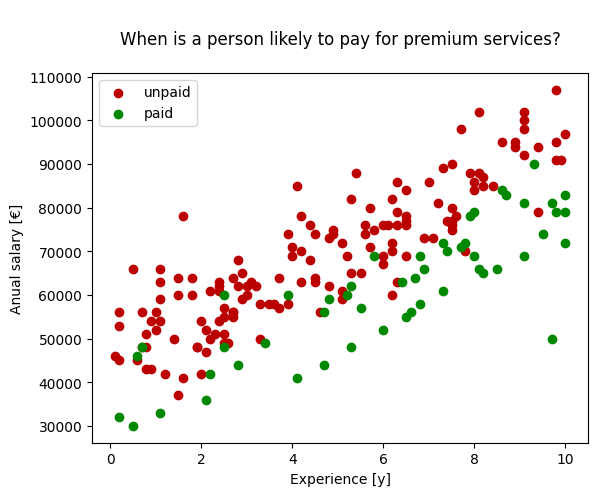

In [3]:
# visualize
x_0 = tuples[:, 0][np.where(tuples[:, 2] == 0)]
x_1 = tuples[:, 0][np.where(tuples[:, 2] == 1)]

y_0 = tuples[:, 1][np.where(tuples[:, 2] == 0)]
y_1 = tuples[:, 1][np.where(tuples[:, 2] == 1)]

plt.scatter(x_0, y_0, c="#bb0000")
plt.scatter(x_1, y_1, c="#008800")
plt.title("\nWhen is a person likely to pay for premium services?\n")
plt.legend(["unpaid", "paid"])
plt.xlabel("Experience [y]")
plt.ylabel("Anual salary [€]")
plt.show()

<span style="font-size: 70%">It is good practice (but additional labour) to add axis labels and legends to the graph.</span>
<br><br>

__Interpretation__: Lower paid people are more likely to pay for premium services than people with higher income.

Can we predict that?

<function matplotlib.pyplot.show(close=None, block=None)>

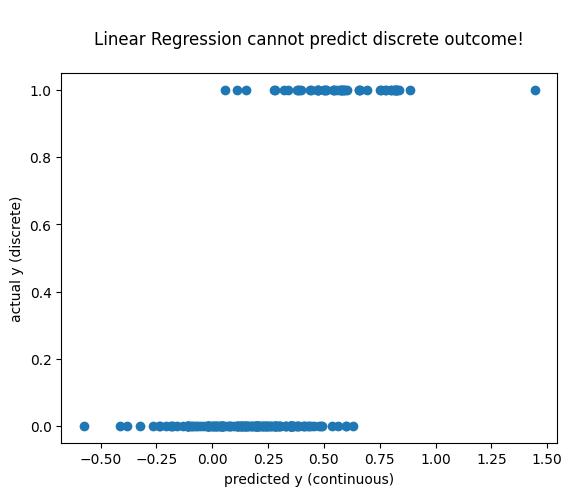

In [4]:
X = tuples[:, :2]
y = tuples[:, 2]

lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)

plt.scatter(y_pred, y)
plt.title("\nLinear Regression cannot predict discrete outcome!\n")
plt.xlabel("predicted y (continuous)")
plt.ylabel("actual y (discrete)")
plt.show

<span style="font-size: 70%">__Note__: The book "__Data Science from Scratch__" uses native Python to demonstrate this. We use `Scikit Learn` which provides the same results for didactic purposes.</span>

Not helpful.


### Model

We look for a function that returns:

$y \in \left [ 0, 1 \right]$ 

$ \to $ and thus our

Hypothesis: 

$ 0 \le h_\theta \left( x \right) \le 1 $

$ h_\theta \left( x \right) = g \left( \theta^T \cdot x \right) $ &nbsp; ... with $ g \left( z \right) = \frac{1}{1 + e^{(-z)}} $

Our Hypothesis should have probabilities:

$ h_\theta \left( x \right) = P \left( y = 1 | x \ge 0 \right) $ &nbsp; and &nbsp; $ = 1 - P \left( y = 0 | x \lt 0 \right) $

$ \to P \left( y = 1 | x \ge 0 \right) + P \left( y = 0 | x \lt 0 \right) = 1 $

Decision boundaries:

> &nbsp;  
> $ h_\theta \left( x \right) \ge 0.5 $ &nbsp; $ \to $ &nbsp; $ y = 1 $
> <br>  
> $ h_\theta \left( x \right) \lt 0.5 $ &nbsp; $ \to $ &nbsp; $ y = 0 $
> <br><br>


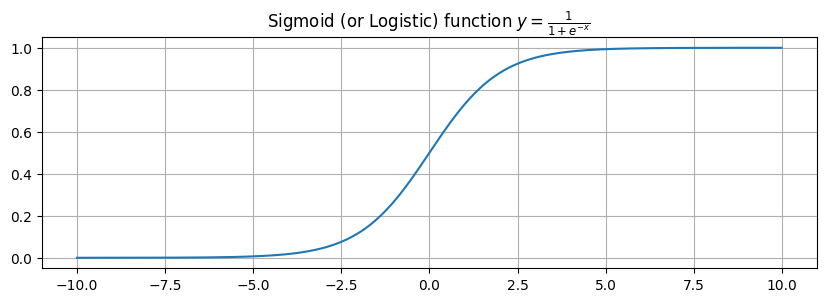

In [5]:
X = np.arange(-10, 10, 0.01)
y = 1.0 / (1.0 + np.exp(-X))

fig = plt.figure(figsize=(10, 3))
plt.grid(visible=True)
plt.plot(X, y)
plt.title(r"Sigmoid (or Logistic) function $y = \frac {1}{1+e^{-x}}$")
plt.show()

Cost function:

$ J \left( \theta \right) = \frac{1}{m} \cdot \sum \left[ y \cdot \log \left( h_\theta \left( x \right) \right) + (1 - y) \cdot \left( 1 - h_\theta \left( x \right) \right) \right] $
<br>

##### Vectorized:

> &nbsp;  
> Hypothesis: &nbsp; $ h = g \left( X \cdot \theta \right) $
> <br><br>

> &nbsp;  
> Cost function: &nbsp; $ J \left( \theta \right) = \frac{1}{m} \cdot \left( - y^T \cdot \log \left( h \right) - (1 - y)^T \cdot \left( 1 - h \right) \right) $
> <br><br>

<br>
Gradient descent:

$ \theta_j = \theta_j - \alpha \cdot \frac{\partial}{\partial \theta_0} \cdot J \left( \theta \right) $

$ \theta_j = \theta_j - \frac{\alpha}{m} \cdot \sum_{i=1}^{m} \left( h_\theta \left( x^{(i)} \right) - y \right) \cdot x_j $

<br>

Recall that parameter updates should be conducted ___all at once___.

<br>

##### $ \to $ Vectorized gradient descent

> &nbsp;  
> Parameters: &nbsp; $ \theta = \theta - \frac{\alpha}{m} \cdot X^T \cdot \left( g \left( X \cdot \theta - \overrightarrow{y} \right) \right) $
> <br><br>

> &nbsp;  
> Cost function: &nbsp; $ \nabla J\left( \theta \right) = \frac{1}{m} \cdot X^T \cdot \left( X \cdot \theta - \overrightarrow y \right) $
> <br><br>

<br>

<img src="./img/0_critical_evaluation.png" width="150px">

### A final word of warning

`Logistic regression` can __distinguish only between two__ classes.

To circumvent this, a model is trained in a __One versus Rest__ fashion.

Separate models are ___trained for each class___  
predicting whether an observation is true for that specific class  
effectively making it a ___binary classification problem___.


### IRIS Classification using Logistic Regression

In [6]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, accuracy_score

In [7]:
# prepare the data
iris = load_iris()

In [8]:
# prepare data for model building with scikit-learn

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [9]:
# model generation
# for details on solvers, refer to https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
# for documentation on LogisticRegression() refer to https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

log = LogisticRegression(max_iter=1000)
log.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
y_pred=log.predict(X_test)

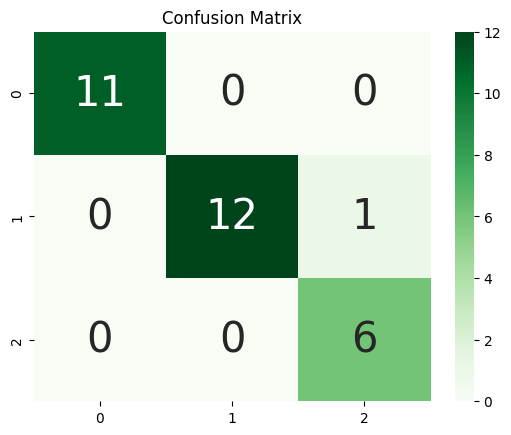

Accuracy:
 Train: 98.33 %
 Test:  96.67 %


In [11]:
# generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# visualize the confusion matrix
ax = plt.axes()
sns.heatmap(cm, annot=True, annot_kws={"size": 30}, cmap="Greens", ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

print('Accuracy:')
print(f' Train: {accuracy_score(y_train, log.predict(X_train))*100:.2f} %')
print(f' Test:  {accuracy_score(y_test, y_pred)*100:.2f} %')

In [12]:
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy of our model is equal {str(round(accuracy, 2))} %.')

Accuracy of our model is equal 96.67 %.


##### Decision boundaries

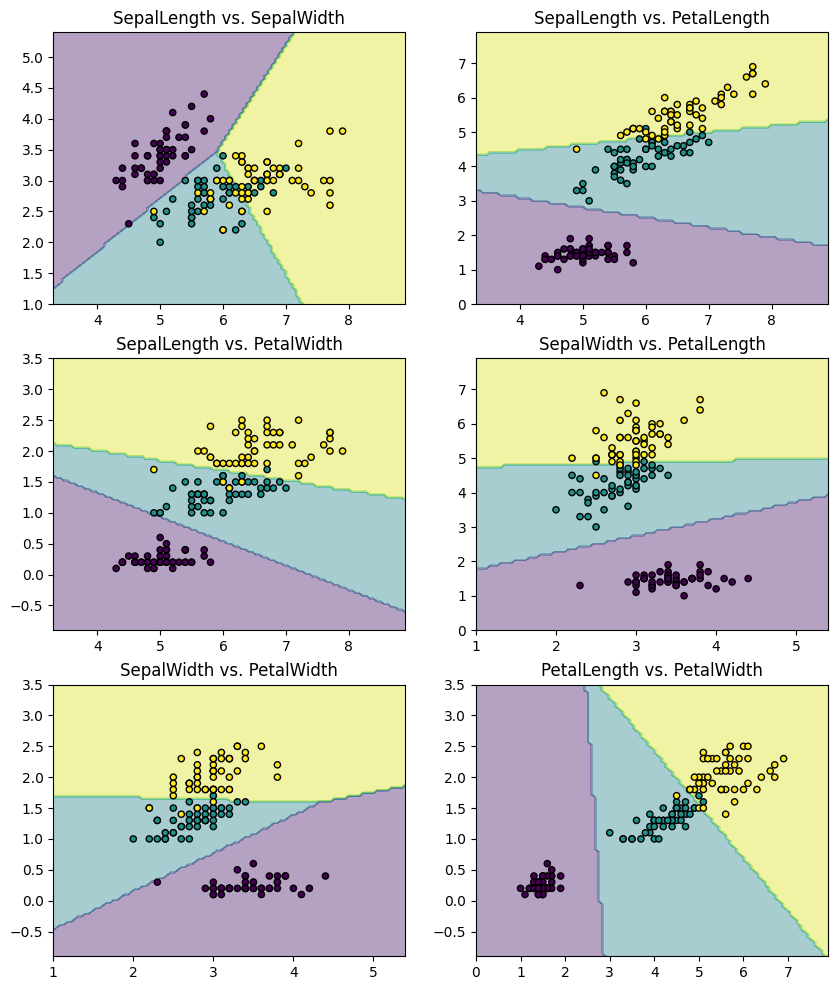

In [13]:
# only needed for display of decission boundaries
from itertools import product
from sklearn.inspection import DecisionBoundaryDisplay

# create a dataframe for statistic evaluation
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
df = pd.DataFrame(iris.data, columns=feature_columns)
df['Species'] = pd.Series(iris.target_names[iris.target])

# all combinations to compare
X_cols_combo = [["SepalLengthCm", "SepalWidthCm"], ["SepalLengthCm", "PetalLengthCm"],
                ["SepalLengthCm", "PetalWidthCm"], ["SepalWidthCm", "PetalLengthCm"],
                ["SepalWidthCm", "PetalWidthCm"], ["PetalLengthCm", "PetalWidthCm"]]

# comparing datasets
X1 = df[X_cols_combo[0]].to_numpy()
X2 = df[X_cols_combo[1]].to_numpy()
X3 = df[X_cols_combo[2]].to_numpy()
X4 = df[X_cols_combo[3]].to_numpy()
X5 = df[X_cols_combo[4]].to_numpy()
X6 = df[X_cols_combo[5]].to_numpy()
y = iris.target

# generating a forrest of classifiers
clf_1 = LogisticRegression(max_iter=1000)
clf_2 = LogisticRegression(max_iter=1000)
clf_3 = LogisticRegression(max_iter=1000)
clf_4 = LogisticRegression(max_iter=1000)
clf_5 = LogisticRegression(max_iter=1000)
clf_6 = LogisticRegression(max_iter=1000)

# make things iterable
clf_all = [clf_1, clf_2, clf_3, clf_4, clf_5, clf_6]
X_sets = [X1, X2, X3, X4, X5, X6]

# helper to generate the image position
img_pos = [pos_t for pos_t in product([0, 1, 2], [0, 1])]

f, ax = plt.subplots(3, 2, figsize=(10, 12))

for i, classifier in enumerate(clf_all):
    classifier.fit(X_sets[i], y)
    DecisionBoundaryDisplay.from_estimator(
        classifier, X_sets[i], alpha=0.4, ax=ax[img_pos[i][0], img_pos[i][1]], response_method="predict")
    ax[img_pos[i][0], img_pos[i][1]].scatter(
        X_sets[i][:, 0], X_sets[i][:, 1], c=y, s=20, edgecolor="k")
    ax[img_pos[i][0], img_pos[i][1]].set_title(
        f"{X_cols_combo[i][0][:-2]} vs. {X_cols_combo[i][1][:-2]}")


### Evaluation of the implementation

Using default parameters leads to convergence warnings.


In [14]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

To fix this, one can change the ___number of iterations___, the model uses (similar to the epochs in Linear Regression with gradient descent).

> &nbsp;  
> logreg = LogisticRegression(max_iter=1000)
> <br><br>

Another option (with difficile impact on the classification results) is to use different - problem specific - ___solvers___. Several solvers can be used:

> &nbsp;
> - lbfgs
> - liblinear
> - newton-cg
> - newton-cholesky
> - sag
> - saga
> <br><br>

Finally, Logistic Regression allows to penalize the outcome of the cost function (___penalty___) or adjust the tolerance of the stop criteria (___tol___).
<br><br>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task: Experiment</h5>
<ul>
    <li>Adjust the maximum iterations. When does the warning disappear?</li>
    <li>Experiment with the solver. Which solver provides the best results (highest accuracy)?</li>
</ul>
</td>
</tr>
</table>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Read about <a href="https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression">Logistic Regression</a> in Scikit Learn</li>
<li>Read about <a href="https://scikit-learn.org/stable/modules/linear_model.html#solvers">Solvers</a></li>
</ul>
</td>
</tr>
</table>

&nbsp;

# Feature scaling

`Logistic Regression` is a little picky about the spread of the features.

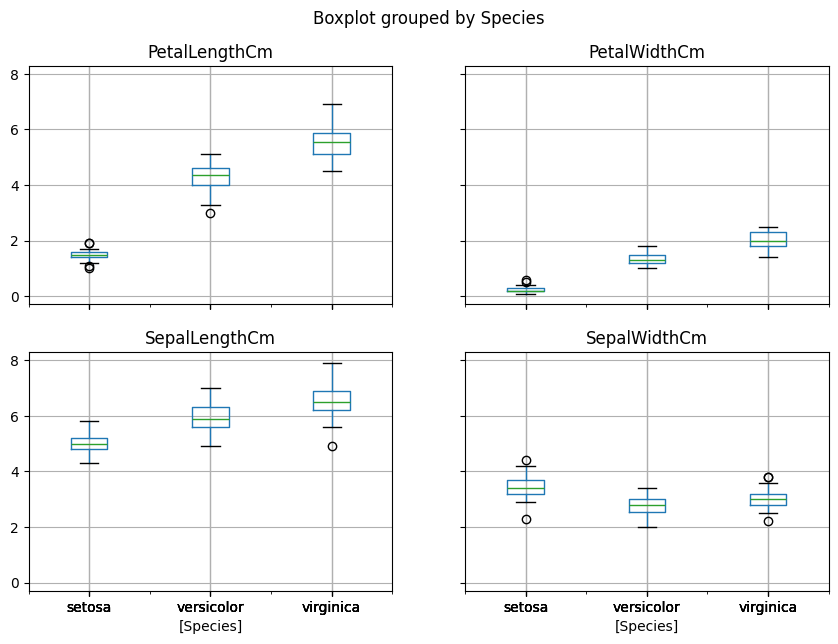

In [15]:
# check distribution
df.boxplot(by="Species", figsize=(10,7))
plt.show()

The Petal length varies significantly between `Iris setosa` and `Iris virginica`.

<br><br>

<img src="./img/5_feature_scaling.png" width="700px"><br><br>

We can calculate:

$ x_{js} = \frac{x_j - \mu_j}{s_j} $ &nbsp; ... with &nbsp; $ s_j = \max \left( x_j \right) - \min \left( x_j \right) $

This leads to:

<img src="./img/5_feature_scaling2.png" width="550px"><br><br>

`Scikit Learn` offers a StandardScaler to provide feature scaling.

In [16]:
from sklearn.preprocessing import StandardScaler, Normalizer

X = np.arange(6)
y = np.array([10, 100000, 1000, 100, 200, 10000])

<BarContainer object of 6 artists>

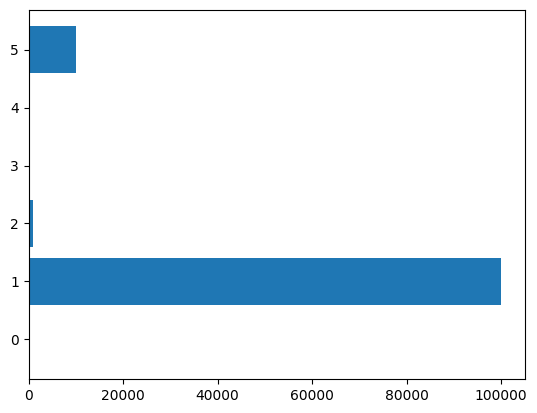

In [17]:
plt.barh(X, y)

<BarContainer object of 6 artists>

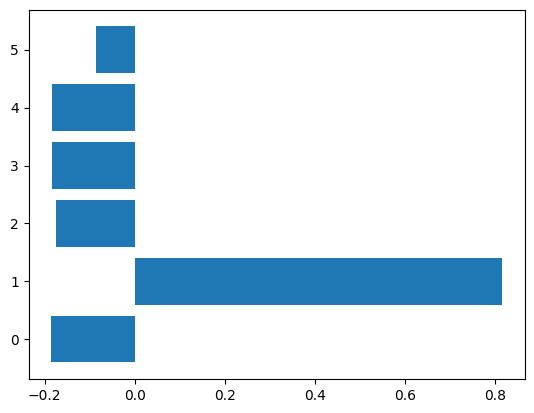

In [18]:
# calculate normalized y_norm
y_mean = np.mean(y)
y_s = np.max(y) - np.min(y)
y_norm = (y - y_mean)/y_s
plt.barh(X, y_norm)

<BarContainer object of 6 artists>

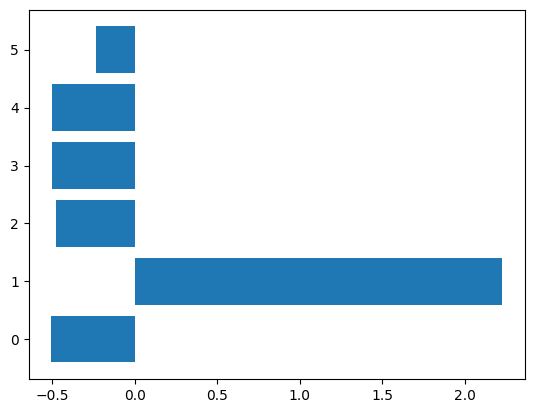

In [19]:
scaler = StandardScaler()
scaler.fit(y.reshape(-1, 1), X)

y_scaled = scaler.transform(y.reshape(-1, 1))
# if you want scaling within spread, uncomment the following line
# y_scaled = y_scaled/(y_scaled.max() - y_scaled.min())

plt.barh(X, y_scaled.reshape(1, -1)[0])

`StandardScaler` scales according to:

$ y_{scaled} = \frac{\left( x - \mu \right)}{\sigma} $

using standard deviation as the spread.

Our normalized Python scaler used:

$ y_{norm} = \frac{\left( x - \mu \right)}{ \left( x_{max} - x_{min} \right)} $

If we want to achieve equal results with the `StandardScaler` we must normalize the scaled results:

$ y_{scaled} = \frac{\left( x - \mu \right)}{\sigma \cdot \left( x_{max} - x_{min} \right)} $

<br><br>

Scaling data is good practice.

- It norms the feature spread of the data
- Some algorithms have problems to converge using data of different scales $ \to $ scaling helps these algorithms to converge
- Scaled data might help reduce computational cost

<br><br>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task:</h5>
<ul>
    <li>Verify that the results are indeed the same when normalizing the scaled values to the spread.</li>
</ul>
</td>
</tr>
</table>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li><a href="https://scikit-learn.org/stable/modules/preprocessing.html">Preprocessing data</a> on Scalers</li>
</ul>
</td>
</tr>
</table>

### Finalizing our initial experiment

How does this apply to our paid account example?

Confusion:
[[29  0]
 [ 6  5]]

Accuracy:
 Train: 88.12 %
 Test:  85.00 %


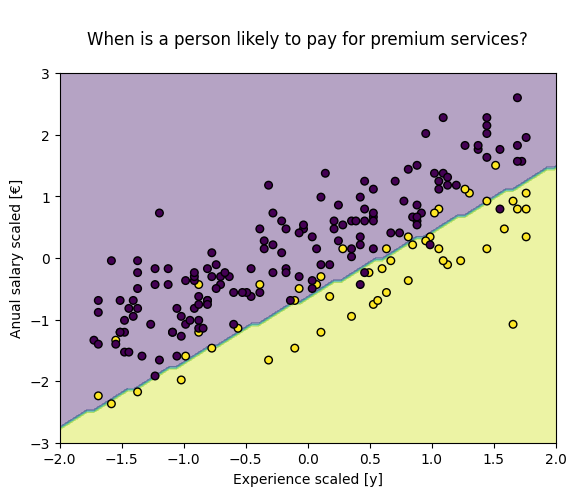

In [20]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

# get data
tuples = np.loadtxt("./data/paid_accounts.csv", delimiter=",")

X = tuples[:, :2]
y = tuples[:, 2]

# prepare - scale - data
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1)

logR = LogisticRegression()
logR.fit(X_train, y_train)

y_pred = logR.predict(X_test)

# model quality
cm = confusion_matrix(y_test, y_pred)
print(f'Confusion:\n{cm}\n')

print('Accuracy:')
print(f' Train: {accuracy_score(y_train, logR.predict(X_train))*100:.2f} %')
print(f' Test:  {accuracy_score(y_test, y_pred)*100:.2f} %')

# decision boundary
DecisionBoundaryDisplay.from_estimator(logR, X_scaled, alpha=0.4, response_method="predict")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=30, edgecolor="k")
plt.title("\nWhen is a person likely to pay for premium services?\n")
plt.xlabel("Experience scaled [y]")
plt.xlim(-2, 2)
plt.ylabel("Anual salary scaled [€]")
plt.ylim (-3, 3)
plt.show()


##### Further predictions

The model is trained on scaled data. 

For further, real-world estimations, one has to scale the input prior to prediction

In [24]:
# assume 1y experience and a salary of € 50.000,-
# the sample is similar to X[18, :]

experience = 1
salary = 56000

X_verify = np.array([experience, salary]).reshape(1, -1)
X_verify_scaled = std_scaler.transform(X_verify)

y_verify_pred = logR.predict(X_verify_scaled)
print(f"Real data target: {y[18]:.0f}\nPredicted target: {y_verify_pred[0]:.0f}")
if y[18] == 0:
    print("Real data: no premium fee paid")
else:
    print("Real data: premium fee paid")
if y_verify_pred[0] == 0:
    print("Predicted: no premium fee paid")
else:
    print("Predicted: premium fee paid")

Real data target: 0
Predicted target: 0
Real data: no premium fee paid
Predicted: no premium fee paid


<span style="font-size: 128px">&#9749;</span> Coffee break!